# 💠 Face Shape Analysis
This notebook classifies your geometric face shape (Oval, Round, Square, etc.) by analyzing the proportions between your facial length, forehead width, cheekbone width, and jaw width.

In [89]:
import cv2
import math
import numpy as np
import mediapipe as mp
import urllib.request
import os
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import warnings
warnings.filterwarnings('ignore')

print(f"MediaPipe {mp.__version__} | OpenCV {cv2.__version__}")

MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print("Downloading Face Landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, MODEL_PATH)

def extract_landmarks(image_path):
    img = cv2.imread(image_path)
    if img is None: raise ValueError(f"Could not read {image_path}")
    h, w, _ = img.shape
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=1,
        min_face_detection_confidence=0.1,
        min_face_presence_confidence=0.1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        res = detector.detect(mp_image)
        if not res.face_landmarks:
            raise ValueError("No face detected!")
        return res.face_landmarks[0], img, rgb, h, w


MediaPipe 0.10.35 | OpenCV 5.0.0


In [90]:
# 8-Point Facial Polygon Indices
# Right Side (visually left), Left Side (visually right)
POINTS = {
    "Top": 10,
    "Right Temple": 103,
    "Right Cheekbone": 234,
    "Right Jaw": 132,
    "Chin": 152,
    "Left Jaw": 361,
    "Left Cheekbone": 454,
    "Left Temple": 332
}

def pt(lm, idx, w, h):
    return np.array([lm[idx].x * w, lm[idx].y * h])

def analyze_shape(lm, w, h):
    import numpy as np
    p_top = pt(lm, POINTS["Top"], w, h)
    p_chin = pt(lm, POINTS["Chin"], w, h)
    p_rt = pt(lm, POINTS["Right Temple"], w, h)
    p_lt = pt(lm, POINTS["Left Temple"], w, h)
    p_rc = pt(lm, POINTS["Right Cheekbone"], w, h)
    p_lc = pt(lm, POINTS["Left Cheekbone"], w, h)
    p_rj = pt(lm, POINTS["Right Jaw"], w, h)
    p_lj = pt(lm, POINTS["Left Jaw"], w, h)
    
    # --- SYNTHETIC FOREHEAD EXPANSION ---
    # MediaPipe's mesh naturally cuts off below the hairline.
    # We use a VERY subtle extrapolation to reach the hairline without over-extending into the hair.
    core_height = np.linalg.norm(p_chin - pt(lm, 9, w, h)) # Chin to Nasion
    
    # Push top point up slightly to hit natural hairline
    p_top[1] -= core_height * 0.15
    
    # Push temples up slightly (to sit halfway up forehead) and very slightly out
    p_rt[1] -= core_height * 0.10
    p_rt[0] -= core_height * 0.015
    
    p_lt[1] -= core_height * 0.10
    p_lt[0] += core_height * 0.015
    
    # Mathematical Distances
    facial_length = np.linalg.norm(p_top - p_chin)
    midface_width = np.linalg.norm(p_rc - p_lc)
    forehead_width = np.linalg.norm(p_rt - p_lt)
    jaw_width = np.linalg.norm(p_rj - p_lj)
    
    # Classification Logic
    ratio = facial_length / midface_width
    if ratio > 1.45:
        length = "Long"
    elif ratio < 1.25:
        length = "Short"
    else:
        length = "Average"
        
    fh_ratio = forehead_width / midface_width
    if fh_ratio > 0.85:
        forehead = "Wide"
    elif fh_ratio < 0.75:
        forehead = "Narrow"
    else:
        forehead = "Normal"
        
    jaw_ratio = jaw_width / midface_width
    if jaw_ratio > 0.85:
        lower_third = "Wide"
    elif jaw_ratio < 0.75:
        lower_third = "Narrow"
    else:
        lower_third = "Normal"
        
    # Determine shape
    shape = "Oval"
    if length == "Average":
        if lower_third == "Wide" and forehead == "Wide":
            shape = "Square"
        elif lower_third == "Narrow":
            shape = "Heart"
        elif forehead == "Narrow" and lower_third == "Normal":
            shape = "Round"
        else:
            shape = "Oval"
    elif length == "Short":
        if lower_third == "Wide":
            shape = "Square"
        else:
            shape = "Round"
    elif length == "Long":
        if forehead == "Wide" and lower_third == "Wide":
            shape = "Oblong"
        else:
            shape = "Oval"
            
    res = {
        "Shape": shape,
        "Facial Length": length,
        "Forehead Width": forehead,
        "Midface Width": "Normal", # Cheekbones are the baseline
        "Lower Third Width": lower_third,
        "Pts": [p_top, p_rt, p_rc, p_rj, p_chin, p_lj, p_lc, p_lt]
    }
    return res


In [91]:
def draw_dashed_line(img, pt1, pt2, color, thickness, gap=10):
    dist = np.linalg.norm(pt2 - pt1)
    pts = int(dist / gap)
    if pts < 2:
        cv2.line(img, (int(pt1[0]), int(pt1[1])), (int(pt2[0]), int(pt2[1])), color, thickness, cv2.LINE_AA)
        return
    for i in range(pts):
        if i % 2 == 0:
            start = pt1 + (pt2 - pt1) * (i / pts)
            end = pt1 + (pt2 - pt1) * ((i+1) / pts)
            cv2.line(img, (int(start[0]), int(start[1])), (int(end[0]), int(end[1])), color, thickness, cv2.LINE_AA)

def draw_face_shape(img_rgb, res):
    h, w = img_rgb.shape[:2]
    
    # Upscale canvas for smooth anti-aliased drawing
    target_h = max(h, 1200)
    upscale = target_h / h
    
    if upscale > 1.0:
        target_w = int(w * upscale)
        img = cv2.resize(img_rgb, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
    else:
        img = img_rgb.copy()
        
    scale = target_h / 800.0
    pts = [p * upscale for p in res["Pts"]]
    
    # 1. Draw the Octagon Polygon
    cv_pts = np.array([[int(p[0]), int(p[1])] for p in pts], np.int32)
    cv_pts = cv_pts.reshape((-1, 1, 2))
    cv2.polylines(img, [cv_pts], isClosed=True, color=(255, 255, 255), thickness=max(1, int(1.5*scale)), lineType=cv2.LINE_AA)
    
    # 2. Draw the Smooth Ellipse Overlaid
    # Fit an ellipse to the face bounding box points
    box_w = np.linalg.norm(pts[2] - pts[6])
    box_h = np.linalg.norm(pts[0] - pts[4])
    center = ((pts[0][0] + pts[4][0]) / 2, (pts[0][1] + pts[4][1]) / 2)
    
    axes = (int(box_w / 2), int(box_h / 2))
    cv2.ellipse(img, (int(center[0]), int(center[1])), axes, 0, 0, 360, (255, 255, 255), max(1, int(1.5*scale)), cv2.LINE_AA)
    
    # 3. Draw Dashed Crosshairs
    # Vertical (Top to Chin)
    draw_dashed_line(img, pts[0], pts[4], (255, 255, 255), max(1, int(1.2*scale)), gap=int(10*scale))
    # Horizontal (Cheekbone to Cheekbone)
    draw_dashed_line(img, pts[2], pts[6], (255, 255, 255), max(1, int(1.2*scale)), gap=int(10*scale))
    
    return img


Please select the FRONTAL face photo in the popup window...
Processing: C:/Users/PratikJPatel/Downloads/360_F_276114144_xyAwCmx6IraojhvC2l9cNQEYAx6d28Nq.jpg

             💠 FACE SHAPE REPORT

  Shape:             Oval
  Facial Length:     Average
  Forehead Width:    Normal
  Midface Width:     Normal
  Lower Third Width: Wide



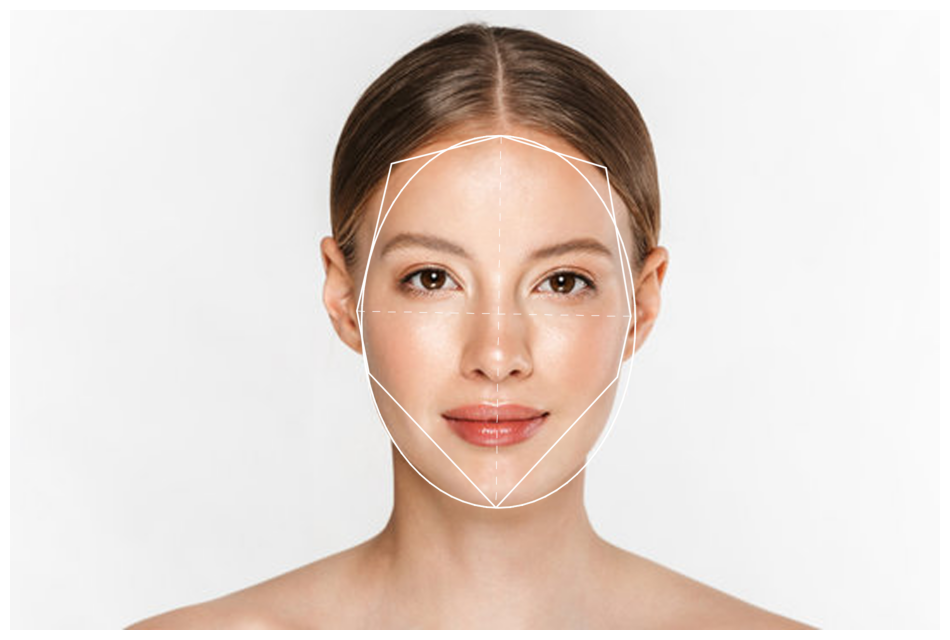

In [92]:
print('Please select the FRONTAL face photo in the popup window...')
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
IMAGE_PATH = filedialog.askopenfilename(title="Select Frontal Photo", filetypes=[('Image files', '*.jpg *.jpeg *.png')])
root.destroy()

if not IMAGE_PATH:
    raise ValueError("No image selected.")

print(f"Processing: {IMAGE_PATH}")

lm, bgr, rgb, h, w = extract_landmarks(IMAGE_PATH)
res = analyze_shape(lm, w, h)
out_img = draw_face_shape(rgb, res)

print("\n=========================================================")
print("             💠 FACE SHAPE REPORT")
print("=========================================================\n")

print(f"  Shape:             {res['Shape']}")
print(f"  Facial Length:     {res['Facial Length']}")
print(f"  Forehead Width:    {res['Forehead Width']}")
print(f"  Midface Width:     {res['Midface Width']}")
print(f"  Lower Third Width: {res['Lower Third Width']}")

print("\n=========================================================")

plt.figure(figsize=(12, 12))
plt.imshow(out_img)
plt.axis("off")
plt.show()
